# Segmentando lóculos complejos

In this tutorial we'll go over how to segmentate fruits with complex locules using `FruitInternalAnalyzer`. 

In [1]:
import traitly
print(f'Traitly version used in this tutorial: {traitly.__version__}')

# Import External Analysis Class
from traitly.fruit_phenotyping import FruitInternalAnalyzer

Traitly version used in this tutorial: 0.1.0


En `FruitInternalAnalyzer`, los contornos de los frutos y sus lóculos se detectan mediante una segmentación jerárquica de contornos usando [`cv2.RETR_TREE`](https://docs.opencv.org/4.x/d9/d8b/tutorial_py_contours_hierarchy.html), el cual identifica y organiza contornos anidados, es decir, contornos dentro de otros contornos. En este esquema, el contorno exterior del fruto actúa como contorno padre (parent), mientras que los lóculos internos son detectados como contornos hijos (child), como se muestra en la imagen. Por esta razón, `detect_fruits()` espera que en la máscara binaria el área del fruto sea de color blanco y los lóculos de color negro.

![Contours](../../docs/assets/images/retr_tree_example.png)

# Tomate - Ejemplo 1

Como primer ejemplo usaremos una imagen de tomate. Dado que la imagen contiene un solo fruto con bastante espacio vacío a su alrededor, comenzaremos recortando la imagen con los parámetros x, y, w y h de `load_image()`. Aunque este paso no es obligatorio, ayuda a reducir el uso de memoria y acelerar el procesamiento, ya que limita la búsqueda de contornos al área de interés.

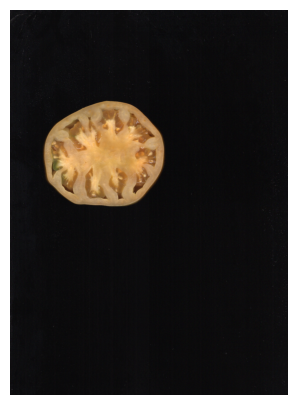

In [2]:
path = "./tomato_2.tif"
tomato = FruitInternalAnalyzer(path)
tomato.load_image()

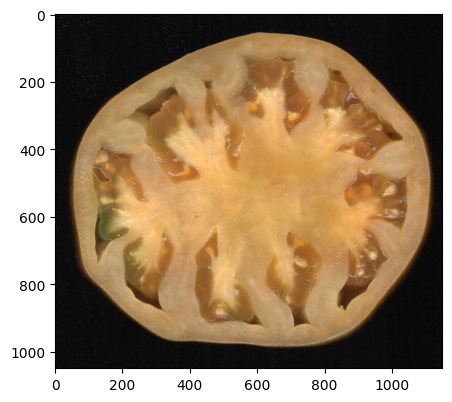

In [3]:
tomato.load_image(show_axis = True, x = 250, y = 750, h = 1050, w = 1150)

Luego, generaremos una máscara para segmentar el fruto con generate_fruit_mask(). Como era de esperarse, al remover únicamente el fondo, todo lo que no es fondo aparece en blanco en esta primera máscara, sin distinción entre el pericarpio y los lóculos.

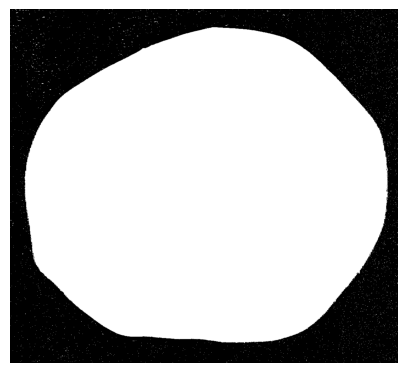

In [4]:
tomato.generate_fruit_mask()

En estos casos, necesitamos crear una máscara adicional de los lóculos a partir de un umbral de intensidad en el canal L (luminosidad) del espacio de color LAB, donde los píxeles más oscuros corresponden a los lóculos y los más claros al resto del fruto. `FruitInternalAnalyzer` convierte internamente la imagen de BGR a LAB y extrae el canal L, por lo que podemos pasar directamente a `generate_locule_mask()`. Sin embargo, cuando el contraste entre el pericarpio y los lóculos no es suficiente para una buena segmentación, podemos mejorarlo previamente con `enhance_locule_contrast()`, el cual permite aplicar una de tres transformaciones al canal L: `'gamma'`, `'sigmoid'` o `'exp'` (exponential). Para más detalles sobre cómo funcionan ambos métodos, ver la sección [Internal Analyzer Class](../../docs/es/workflow/internal_class.md#enhance_locule_contrast).

El parámetro `compare_method=True` genera una visualización comparativa que muestra el resultado de las tres transformaciones frente a la imagen original, usando valores por defecto que pueden ajustarse con los parámetros correspondientes. Esto facilita elegir el método más adecuado antes de aplicarlo.

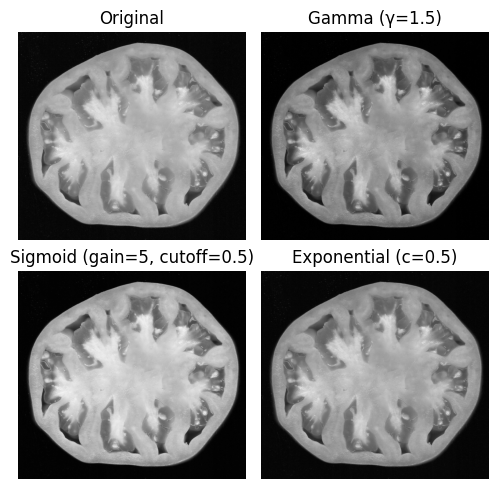

In [5]:
tomato.enhance_locule_contrast(compare_method = True, plot_size = (5,5))

Por defecto, `enhance_locule_contrast(compare_method = True)`, solo muestra el plot pero no aplica ninguna transformación a la imagen a menos que se especifique con el parámetro `contrast_method`. Una vez seleccionado el método, es necesario correr `enhance_locule_contrast()` nuevamente, esta vez pasando el método que hayas elegido en lugar de `compare_method`.

Para este ejemplo usaremos `contrast_method='gamma'`.

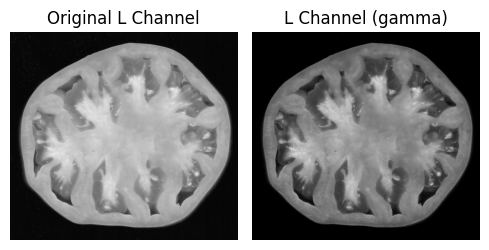

In [6]:
tomato.enhance_locule_contrast(contrast_method = 'gamma', 
                               gamma = 1.8,
                               plot_size = (5,5))

Una vez aplicado el contraste, generaremos la máscara de lóculos con `generate_locule_mask()`. Esta función binariza el canal L transformado usando thresh_min para seleccionar los píxeles oscuros que corresponden a los lóculos, y luego combina internamente esta máscara con la máscara de frutos para producir una máscara final en el formato esperado. Cuando `plot=True` (por defecto), se despliegan en pantalla tanto la máscara intermedia de los lóculos como la máscara final combinada.

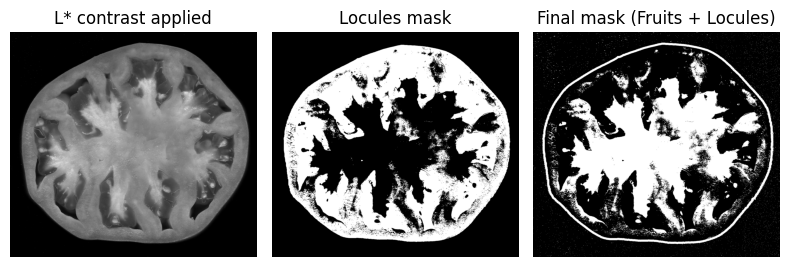

In [7]:
tomato.generate_locule_mask(plot_size = (8,5))

En este fruto, los valores por defecto de `thresh_min` no capturan bien los lóculos, por lo que es necesario ajustar este umbral. Para guiar esta elección, podemos utilizar `generate_l_channel_histogram()`.

!!! note "Requisito previo"
    `generate_l_channel_histogram()` requiere que tanto `generate_fruit_mask()` como `enhance_locule_contrast()` hayan sido ejecutados previamente.

Este método genera dos **histogramas de la distribución de píxeles del canal L**, restringida a los píxeles dentro de la máscara de frutos. El histograma de la izquierda muestra la **distribución completa del canal L**, y el de la derecha muestra la misma **distribución particionada por el umbral de Otsu** (más detalles en [Otsu Binarization](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)), donde la línea punteada indica un posible valor de corte entre lóculos y pericarpio. Con `otsu_offset` puedes desplazar esta línea hacia la izquierda o derecha hasta posicionarla en el punto que mejor separe ambas poblaciones.

El valor identificado en el histograma puede usarse de dos formas en `generate_locule_mask()`: como `thresh_min` para filtrar los pixeles directamente de la imagen del canal L, o pasando `otsu_offset` para que internamente se aplique una binarización con Otsu y se ajuste al valor identificado.

Aquí, en ambos histogramas podemos distinguir una distribución bimodal: la primera moda, con una media aproximada de 70, corresponde a los píxeles oscuros de los lóculos, mientras que la segunda, con una media aproximada de 120, corresponde a los píxeles más claros del pericarpio. Dado que la separación entre ambas poblaciones es más clara en el histograma de Otsu, optamos por usar `otsu_offset` en lugar de `thresh_min` directamente. Seleccionamos como punto de partida `otsu_offset=15`, ya que posiciona mejor la línea punteada en el valle entre ambas modas.

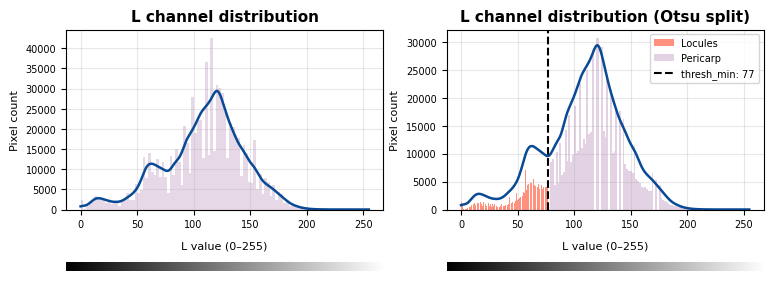

In [8]:
tomato.generate_l_channel_histogram(otsu_offset = 15, plot_size = (9,3))

Al final, seleccionamos un valor de `otsu_offset=25` ajustando ligeramente el umbral de Otsu hasta estar conformes con la máscara final. 

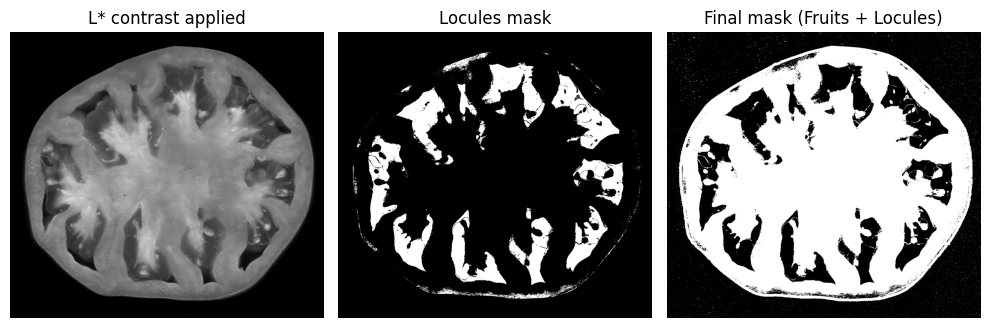

In [9]:
tomato.generate_locule_mask(otsu_offset = 25)

Opcionalmente, puedes usar `erosion_px` para aplicar una erosión a la máscara del fruto y eliminar ruido en los bordes.

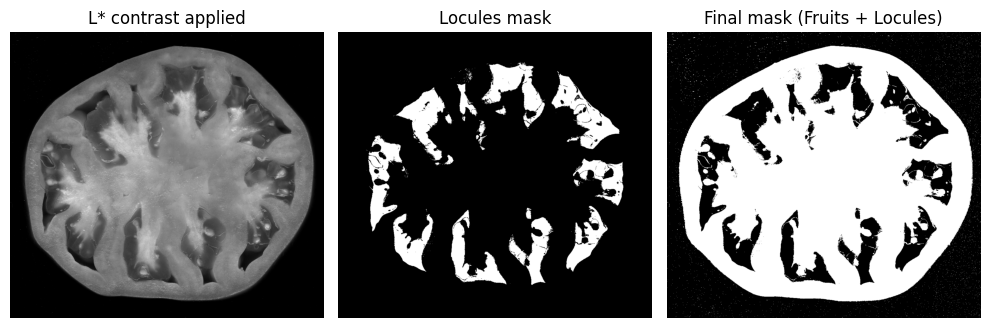

In [10]:
tomato.generate_locule_mask(otsu_offset = 25,
                            erosion_px = 45)

Verificamos los contornos de los lóculos con `detect_fruits()` y eliminamos contornos pequeños con `min_locule_area`


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 1 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_locule_area: 100
        - min_locule_per_fruit: 1
        - min_fruit_area: 5000


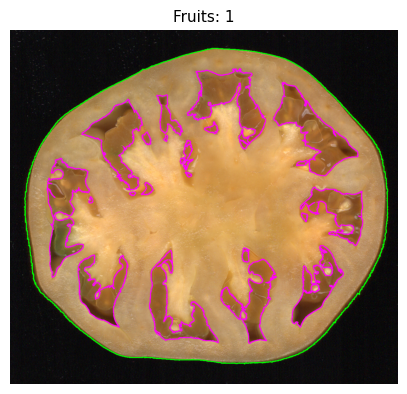

In [11]:
tomato.detect_fruits(plot = True, min_locule_area = 100)

Mediante `generate_single_fruit_masks()` podemos visualizar con más detalle la segmentación de los tejidos del fruto:

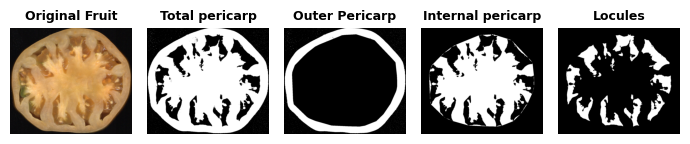

In [12]:
tomato.generate_single_fruit_masks()

Ya con la máscara lista, podemos proseguir con los analisis de color y morfología.

Como vemos en los resultados, a veces con este tipo de máscaras el número de lóculos puede estar sobreestimado debido a que algunos aparecen fraccionados. Por esta razón, las métricas a nivel de lóculo individual no serán confiables; sin embargo, métricas como el área total de lóculos y todas las relacionadas al pericarpio y al fruto en general sí son válidas.

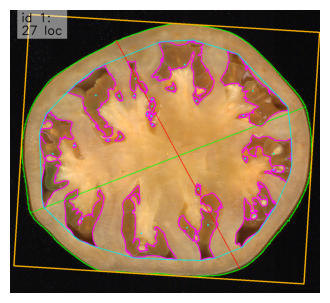

,image_name,label,fruit_id,n_locules,unit,fruit_area_px2,fruit_perimeter_px,fruit_circularity,fruit_solidity,fruit_convexity,...,locules_std_circularity,locules_cv_circularity,locules_angular_symmetry,locules_radial_symmetry,outer_pericarp_to_fruit_ratio,internal_pericarp_to_fruit_ratio,internal_pericarp_to_total_internal_ratio,locules_total_area_px2,locules_to_fruit_ratio,locules_to_total_internal_ratio
0,tomato_2.tif,No label detected,1,27,px,796633.5,3853.406529,0.674185,0.993761,0.832286,...,0.154494,53.071629,0.394732,30.361289,0.23835,0.548719,0.720435,169628.0,0.212931,0.279565


In [13]:
tomato.analyze_morphology(plot_size = (4,4))

En cuanto al analisis de color, la fragmentación de los lóculos no afecta los resultados ya que se cuantifica el color de los pixeles del área total de los lóculos. 

In [14]:
tomato.analyze_color(color_space = 'rgb')

,image_name,label,fruit_id,tissue,R_mean,G_mean,B_mean,R_std,G_std,B_std
0,tomato_2.tif,No label detected,1,locules,149.390747,100.722099,50.299911,24.212488,19.982964,16.352348
1,tomato_2.tif,No label detected,1,total_pericarp,196.901138,151.298660,93.859886,29.664679,24.240587,20.709814
2,tomato_2.tif,No label detected,1,internal_pericarp,209.395004,160.081421,97.765160,19.221958,17.072124,18.259745
3,tomato_2.tif,No label detected,1,outer_pericarp,169.944504,132.782898,86.225906,31.517284,27.423330,23.023228


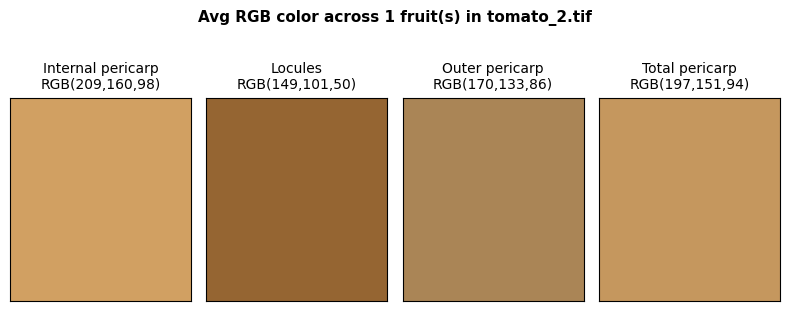

In [48]:
from traitly.fruit_phenotyping import plot_tissue_colors
df = tomato.results.color_results

plot_tissue_colors(df)

# Tomate – Ejemplo 2

En el ejemplo anterior, los lóculos eran significativamente más oscuros que el resto del fruto, pero en algunas imágenes más complejas ciertas regiones del pericarpio pueden tener una intensidad similar a la de los lóculos, como en esta otra imagen de tomate.

Al igual que antes, comenzamos generando la máscara del fruto con `generate_fruit_mask()`.

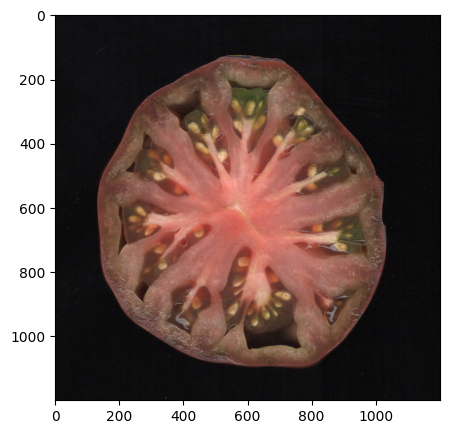

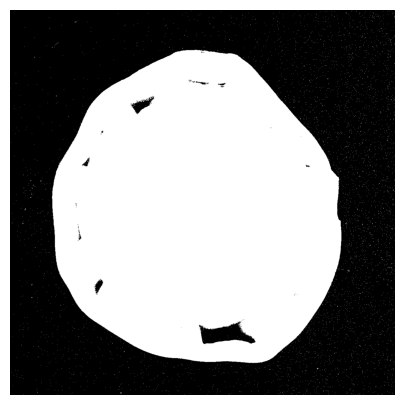

In [16]:
path = "./tomato_1.tif"
tomato = FruitInternalAnalyzer(path)
tomato.load_image(show_axis = True, x = 400, y = 500, w = 1200, h = 1200)
tomato.generate_fruit_mask()


Al revisar `compare_method=True`, notamos que algunos píxeles del pericarpio tienen una intensidad similar a la de los lóculos, por lo que las transformaciones anteriores pueden no ser suficientes para lograr una buena segmentación. Esto también se refleja en el histograma: a diferencia del ejemplo anterior, ambas poblaciones de píxeles se solapan considerablemente, lo que dificulta encontrar un umbral claro que las separe.

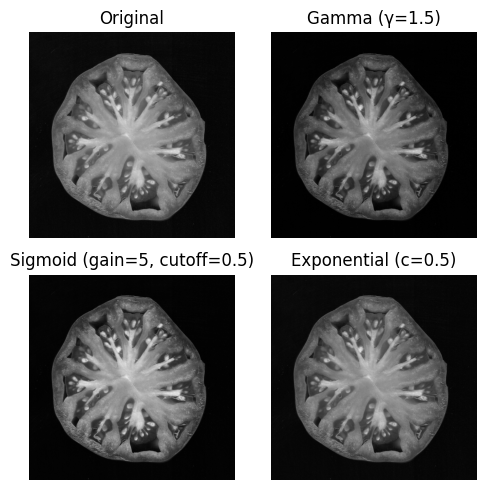

In [17]:
tomato.enhance_locule_contrast(compare_method = True, plot_size = (5,5))

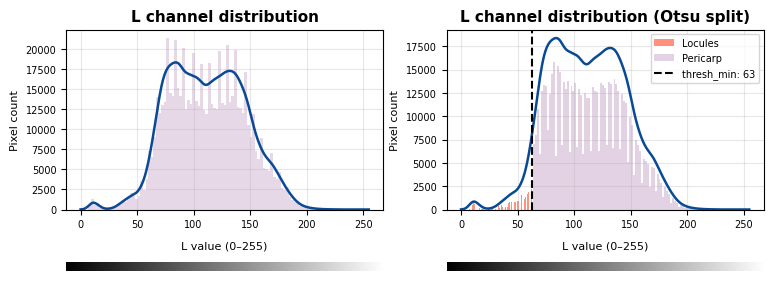

In [18]:
tomato.generate_l_channel_histogram()

Para estos casos, `enhance_locule_contrast()` ofrece la opción de aplicar **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*), una variante de la ecualización de histograma que opera localmente sobre pequeñas regiones de la imagen (*tiles*), mejorando el contraste en áreas específicas sin amplificarlo de forma global. Se controla con dos parámetros: `clip_limit`, que define el límite máximo de amplificación del contraste (valores más altos producen un contraste más pronunciado pero pueden introducir más ruido), y `tile_grid_size`, que determina el tamaño de las regiones locales (valores más altos consideran áreas más grandes, acercándose a una ecualización más global). CLAHE puede aplicarse de forma independiente o en combinación con cualquiera de los métodos de transformación (`'gamma'`, `'sigmoid'`, `'exp'`), en cuyo caso se aplica sobre la imagen ya transformada. Si no se especifica `contrast_method`, CLAHE se aplica directamente sobre el canal L original.

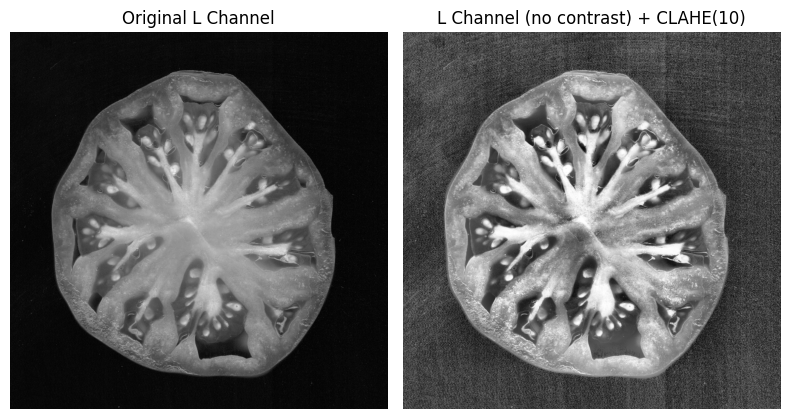

In [19]:
tomato.enhance_locule_contrast(
    contrast_method='none',
    clip_limit=10,
    tile_grid_size=5
)

Al aplicar CLAHE, la distribución de píxeles en el histograma cambia considerablemente respecto a la imagen original, lo que puede afectar el umbral calculado por Otsu. Por esta razón, en lugar de guiarnos por `otsu_offset`, ajustaremos `clip_limit` y `tile_grid_size` hasta obtener la mejor separación entre ambas poblaciones en el histograma, y usaremos directamente `thresh_min` en `generate_locule_mask()`.

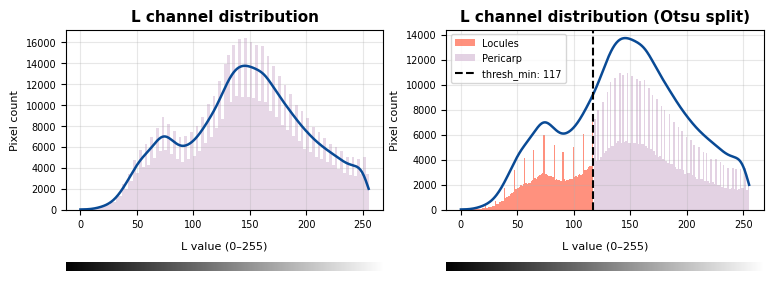

In [20]:
tomato.generate_l_channel_histogram()

La máscara resultante captura la mayor parte de los lóculos, aunque aún persiste algo de ruido difícil de eliminar solo con umbrales. Para corregirlo, podemos usar `edit_mask()`, que abre un editor interactivo para agregar o remover regiones de la máscara manualmente (ver [Internal Fruit Analyzer](../../docs/es/workflow/internal_class.md#edit_mask) para más detalles sobre este método).

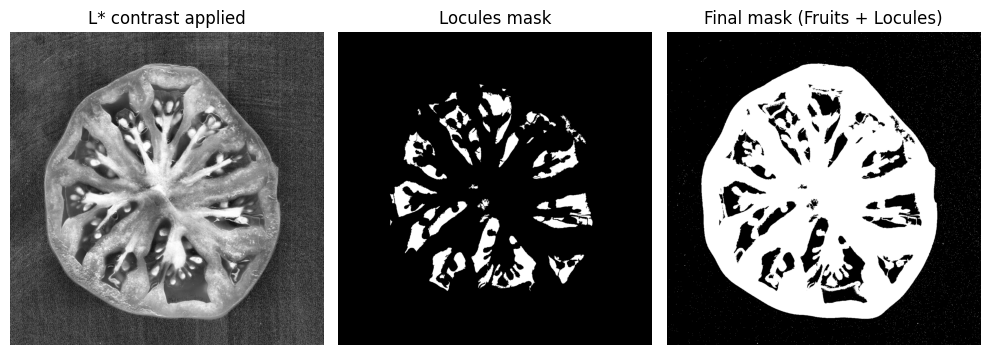

In [21]:
tomato.generate_locule_mask(thresh_min = 90, min_locule_area = 50)

In [22]:
tomato.edit_mask()

La máscara corregida con `edit_mask()` será guardada como `mask_locules`. Vamos a visualizarla con `matplotlib`:

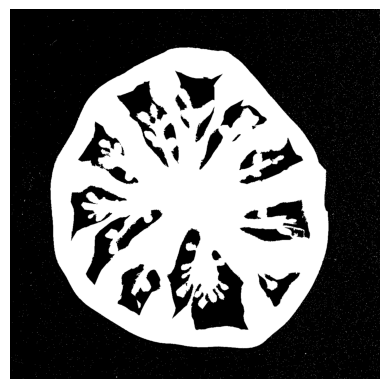

In [23]:
import matplotlib.pyplot as plt

plt.imshow(tomato.mask_locules, cmap = 'gray')
plt.axis('off')
plt.show()


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 1 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_locule_area: 100
        - min_locule_per_fruit: 1
        - min_fruit_area: 5000


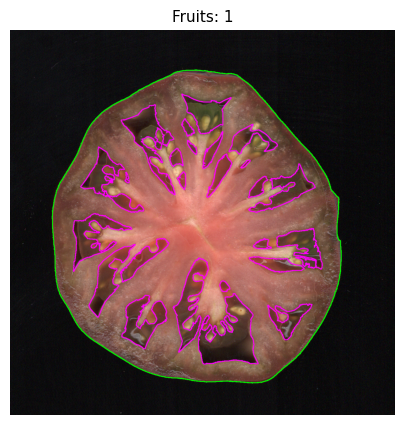

In [24]:
tomato.detect_fruits(plot = True, min_locule_area = 100)

# Pitahaya

En `traitly`, los lóculos se definen como las cavidades internas del fruto rodeadas por tejido de pericarpio. Sin embargo, `generate_locule_mask()` puede usarse para segmentar otros tejidos internos, como la pulpa de la pitahaya, aunque en sentido estricto no se trate de lóculo.

Procederemos de la misma forma que en los ejemplos anteriores: cargando la imagen y generando la máscara del fruto con `generate_fruit_mask()`.

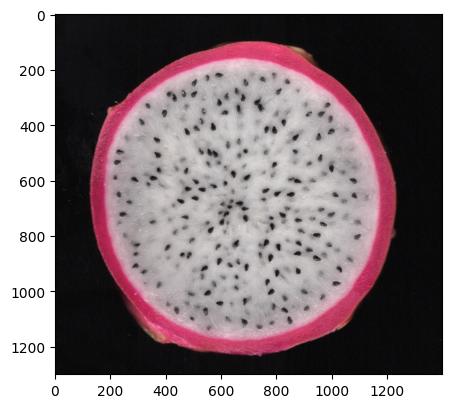

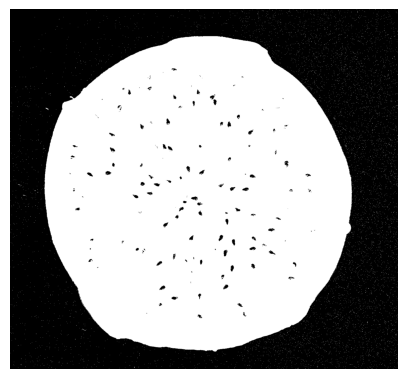

In [2]:
path = './dragon_fruit.tif'

dragon_fruit = FruitInternalAnalyzer(path)
dragon_fruit.load_image(show_axis = True, 
                        x = 400, y = 400, h = 1300, w = 1400)
dragon_fruit.generate_fruit_mask()

Al revisar `compare_method=True`, los métodos de transformación de contraste mejoran ligeramente la separación entre pulpa y cáscara, pero la imagen original es suficiente para continuar, por lo que no aplicaremos ninguna transformación adicional. Como no indicamos `contrast_method`, no se hizo ninguna transformación, por lo que podemos continuar directamente con `generate_l_channel_histogram` y `generate_locule_mask()`.

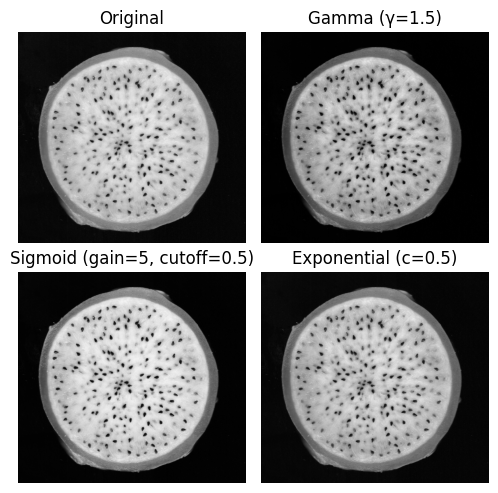

In [3]:
dragon_fruit.enhance_locule_contrast(compare_method = True, plot_size = (5,5))

Al revisar el histograma con `generate_l_channel_histogram()`, observamos que en ambos plots la separación entre los píxeles oscuros y claros es clara, por lo que usaremos directamente `thresh_min=150`.

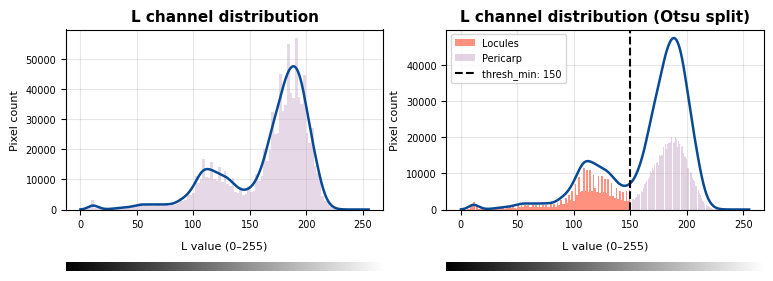

In [4]:
dragon_fruit.generate_l_channel_histogram(otsu_offset = 60)

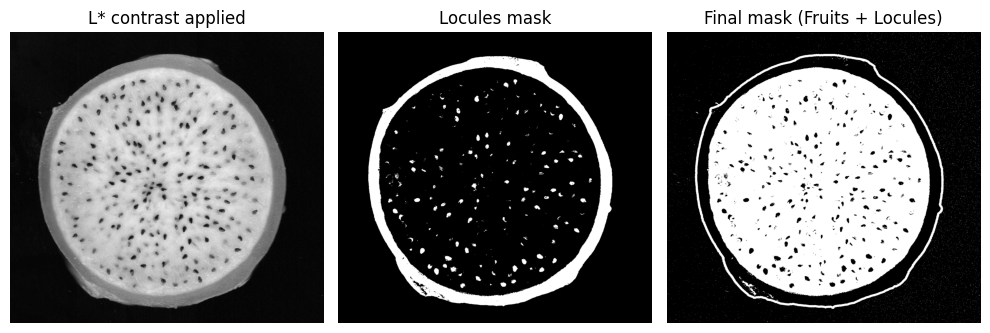

In [32]:
dragon_fruit.generate_locule_mask(thresh_min = 150)

Sin embargo, a diferencia de los ejemplos anteriores, en esta imagen la pulpa es más clara que el resto del fruto. Como `generate_locule_mask()` espera que los lóculos sean más oscuros, usaremos el parámetro `invert_locule=True` para invertir la máscara de lóculos antes de combinarla con la del fruto. En la máscara final, la pulpa aparecerá en negro y el resto del fruto en blanco.

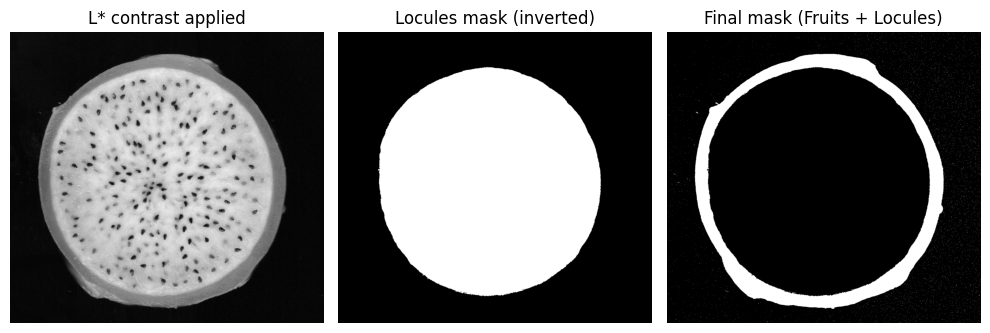

In [5]:
dragon_fruit.generate_locule_mask(thresh_min = 150, invert_locule = True, min_locule_area = 500)


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 1 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_locule_area: 50
        - min_locule_per_fruit: 1
        - min_fruit_area: 5000


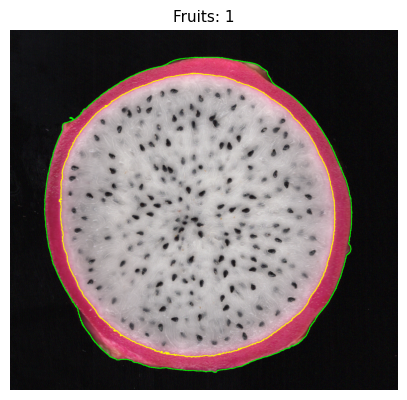

In [6]:
dragon_fruit.detect_fruits(plot = True, pericarp_int_color = (255,255,0))

Ahora ya podemos proceder con `analyze_morphology()` y/o `analyze_color()`. 

Como en este caso solo hay un 'lóculo' que abarca toda la región de la pulpa, antes de correr `analyze_color()` podemos revisar la segmentación de los tejidos con `generate_single_fruit_masks()` y seleccionar solo los que sean informativos. En este fruto, continuaremos únicamente con `'total_pericarp'` y `'locules'`, ya que los demás tejidos no son relevantes para este caso.

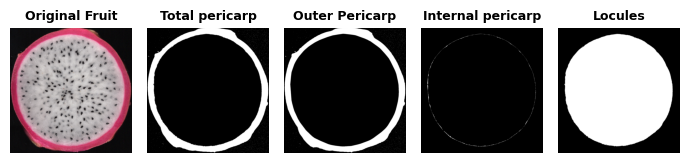

In [7]:
dragon_fruit.generate_single_fruit_masks()

Por defecto, `analyze_color()` excluye los píxeles con un valor de luminosidad por debajo de un umbral de 20 (`dark_thresh=20`) para evitar ruido del fondo o de elementos muy oscuros como las semillas. En esta imagen, este umbral es suficiente para remover el color de las semillas y el ruido del fondo. Si en otras imágenes fuera necesario ajustarlo, podemos apoyarnos en `plot_dark_threshold()`, que muestra la distribución de los píxeles en toda la sección del fruto para identificar el mejor valor de corte, y pasarlo directamente con `dark_thresh` en `analyze_color()`.

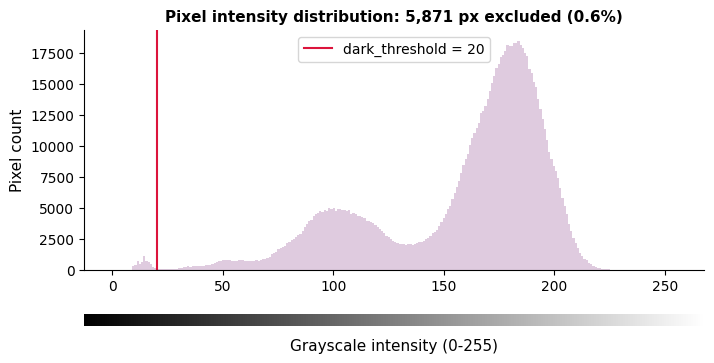

In [33]:
from traitly.fruit_phenotyping import plot_dark_threshold

img = dragon_fruit.img
mask = dragon_fruit.mask_fruit
plot_dark_threshold(img, mask, dark_threshold = 20)


Finalmente, extraemos las métricas de color para el canal RGB con `analyze_color()` y visualizamos el color promedio para los tejidos analizados.

In [34]:
dragon_fruit.analyze_color(tissue = 'outer_pericarp, locules', 
                           dark_thresh = 20,
                           color_space = 'rgb')

,image_name,label,fruit_id,tissue,R_mean,G_mean,B_mean,R_std,G_std,B_std
0,dragon_fruit.tif,No label detected,1,locules,178.877701,167.373367,170.359070,32.970287,31.307421,30.091896
1,dragon_fruit.tif,No label detected,1,outer_pericarp,145.439133,62.993668,76.922646,47.592270,24.424252,28.572855


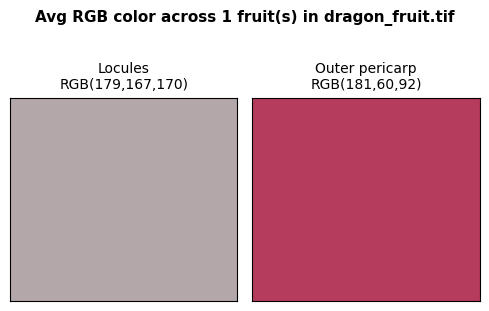

In [19]:
from traitly.fruit_phenotyping import plot_tissue_colors

df = dragon_fruit.results.color_results

plot_tissue_colors(df, 
                   plot_size = (5,3))